# Relaciones entre variables

In [1]:
from proyecto_ciencia_de_datos.config import PROCESSED_DATA_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_EDA_son.csv', sep=',', header='infer', low_memory=False)
inegi_df = pd.read_csv(PROCESSED_DATA_DIR / 'inegi_EDA_son.csv', sep=',', header='infer')
weather_df = pd.read_csv(PROCESSED_DATA_DIR / 'weather_EDA_son.csv', sep=',', header='infer')

2025-11-09 14:04:09.219 | INFO     | proyecto_ciencia_de_datos.config:<module>:11 - PROJ_ROOT path is: D:\MasterHDXD\Escuela\Maestria\Ingenieria_de_caracteristicas\Proyecto\proyecto_ing_datos


## AXA

Una matriz de correlacion para visualizar los valores numericos del dataset

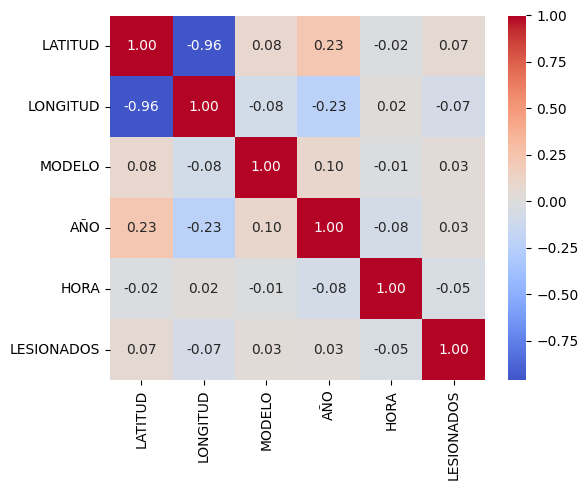

In [2]:
# Create correlation matrix for numerical columns
corr = axa_df[['LATITUD','LONGITUD','MODELO','AÑO','HORA','LESIONADOS']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

### Visualizacion para las variables categoricas

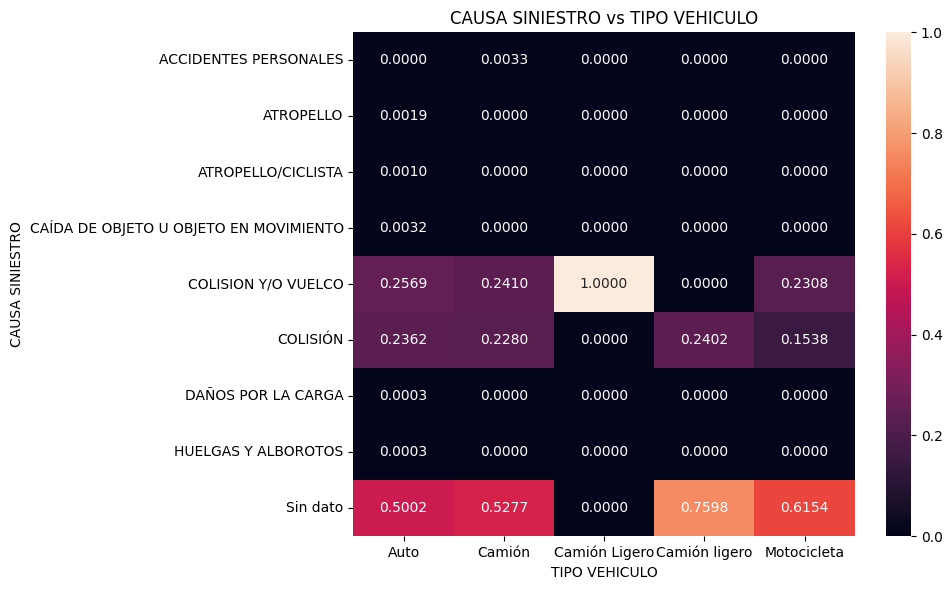

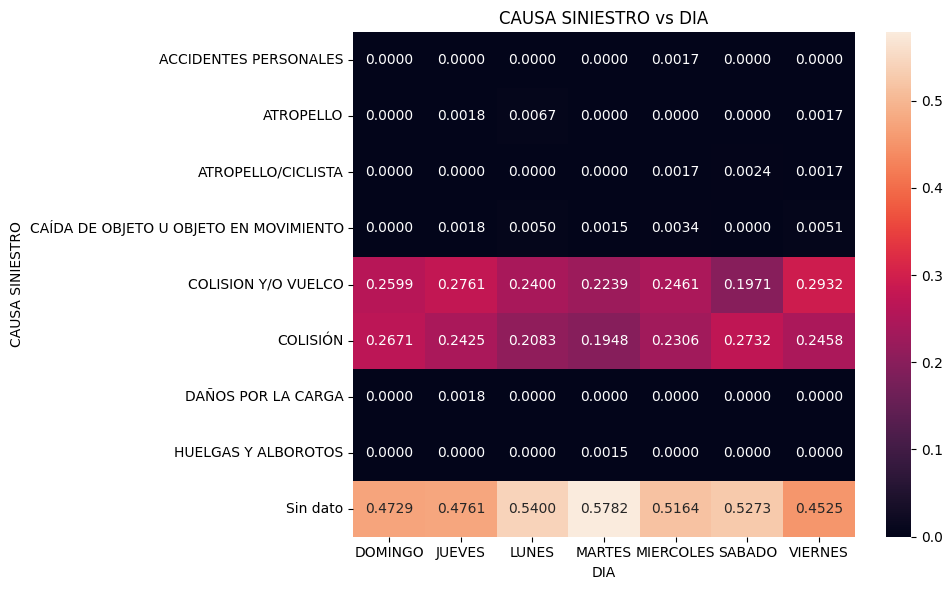

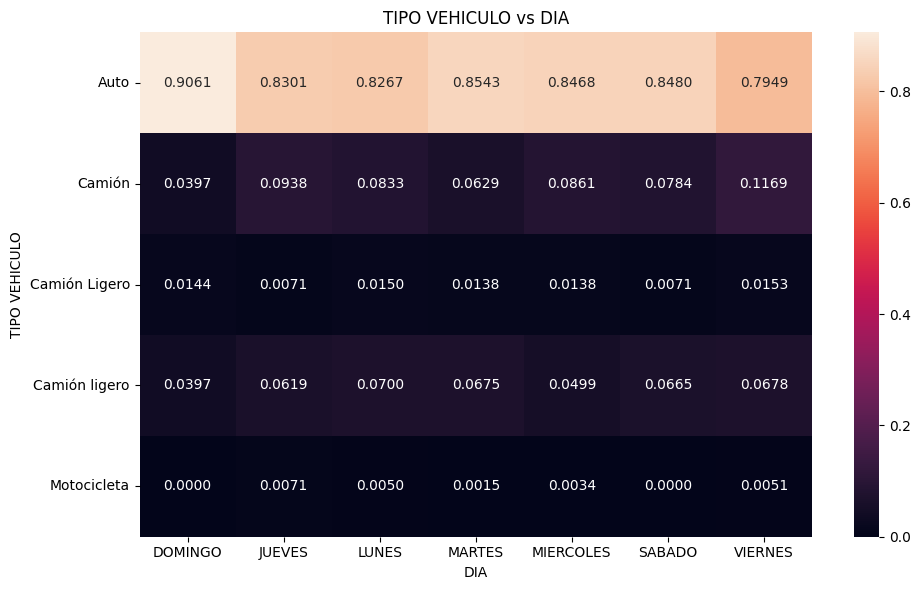

In [3]:
# Lista de columnas categóricas
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']
# Ciudad excluida por que no se ve bien en este tipo de grafico

# Generar combinaciones de dos columnas categóricas
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

# Heatmaps
for col1, col2 in pairs:
    plt.figure(figsize=(10, 6))

    # Tabla de contingencia con categorías completas
    ct = pd.crosstab(
        axa_df[col1],
        axa_df[col2],
        dropna=False,
        normalize='columns'   # Normaliza por fila
    )

    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2}")
    plt.tight_layout()
    plt.show()


OBSERVACIONES:

Podemos observar que:
- Los accidentes más comunes en los datos de AXA son causados por **autos** personales (Por que tienen la mayor cantidad de conductores)
- El día con más accidentes es el **Martes**
- Los accidentes más comunes son **Colisión** y **Colisión Y/O Vuelco** (Excluyendo 'Sin Dato')

La mayoria de correlaciones son hacia los Autos, que pasa si vemos la correlacion sin ellos?

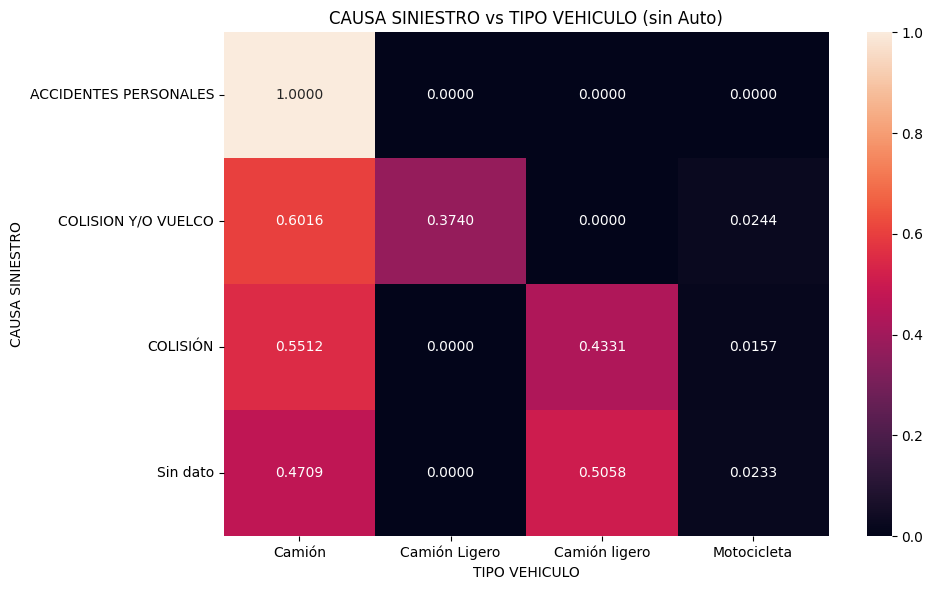

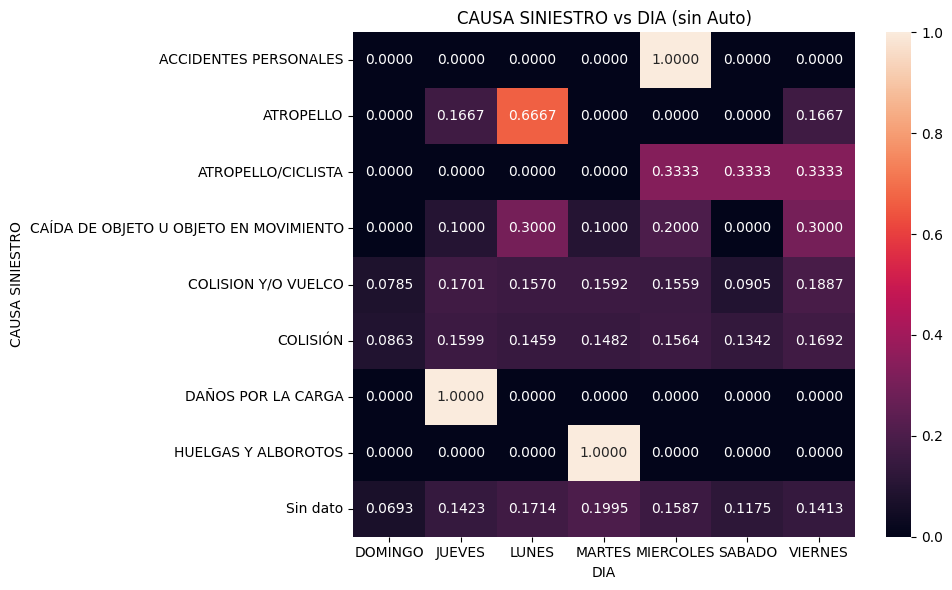

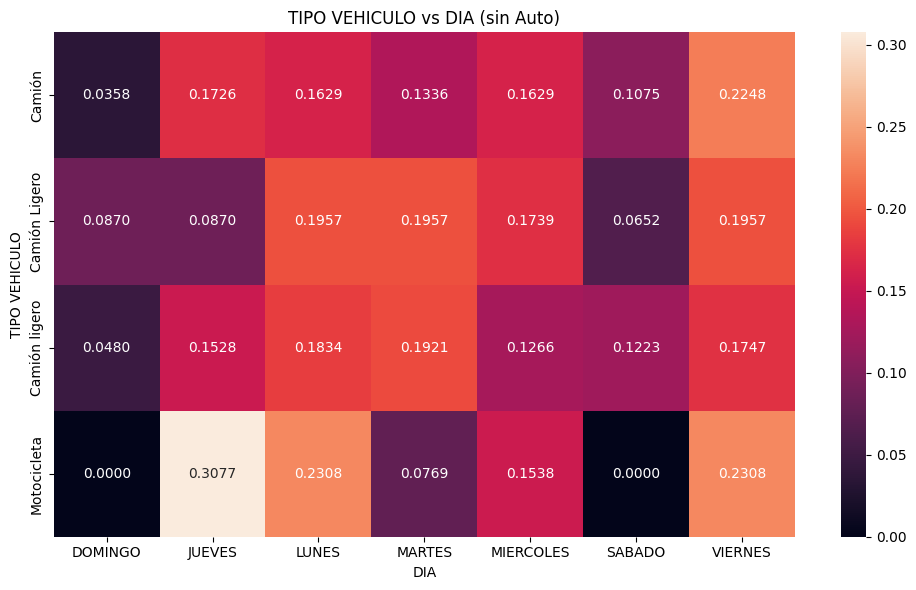

In [4]:
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']

# Generar pares
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

for col1, col2 in pairs:
    # Copia filtrada solo para la gráfica actual
    df_plot = axa_df.copy()

    # Excluir "Auto" cuando TIPO VEHICULO aparece en cualquiera de las dos columnas
    if col1 == 'TIPO VEHICULO' or col2 == 'TIPO VEHICULO':
        df_plot = df_plot[df_plot['TIPO VEHICULO'] != 'Auto']

    # Tabla normalizada por fila
    ct = pd.crosstab(
        df_plot[col1],
        df_plot[col2],
        dropna=False,
        normalize='index'
    )

    # Eliminar filas/columnas de Auto si quedaron en el índice accidentalmente
    if 'Auto' in ct.index:
        ct = ct.drop(index='Auto')
    if 'Auto' in ct.columns:
        ct = ct.drop(columns='Auto')
        

    # Graficar
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2} (sin Auto)")
    plt.tight_layout()
    plt.show()


OBSERVACIONES
Al haber eliminado los autos personales de la grafica, podemos notar nuevas relaciones:

- Los accidentes más comunes en los datos de AXA son causados por *Camiones*
- Ahora ya no hay un día con más accidentes, ya que ahora se distribuye los dias con accidentes en una forma más general 
- Los accidentes más comunes ya no son **Colisión** y **Colisión Y/O Vuelco** pero ahora la cantidad de **'Sin Dato'** se reducío considerablemente, lo cual significa que la mayoria de estos son por **autos** personales
- Los accidentes **Personales** parecen ser causados solamente por **Camión** y solo el **Miercoles**, esto puede ser por que no muchos accidentes son marcados como **Personales** o son registrados como **'Sin Dato'**

## INEGI

In [5]:
inegi_df.columns

Index(['COBERTURA', 'ID_MUNICIPIO', 'ANIO', 'MES', 'ID_HORA', 'ID_MINUTO',
       'ID_DIA', 'DIASEMANA', 'URBANA', 'SUBURBANA', 'TIPACCID', 'AUTOMOVIL',
       'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 'CAMIONETA', 'CAMION',
       'TRACTOR', 'FERROCARRI', 'MOTOCICLET', 'BICICLETA', 'OTROVEHIC',
       'CAUSAACCI', 'CAPAROD', 'SEXO', 'ALIENTO', 'CINTURON', 'ID_EDAD',
       'CLASACC', 'ESTATUS', 'AÑO'],
      dtype='object')

In [6]:
inegi_df['AUTOMOVIL'].value_counts()    

AUTOMOVIL
1    64180
2    52902
0    22670
3     2623
4      227
5       34
6        4
8        1
Name: count, dtype: int64

### Observando relaciones con tipo de accidente

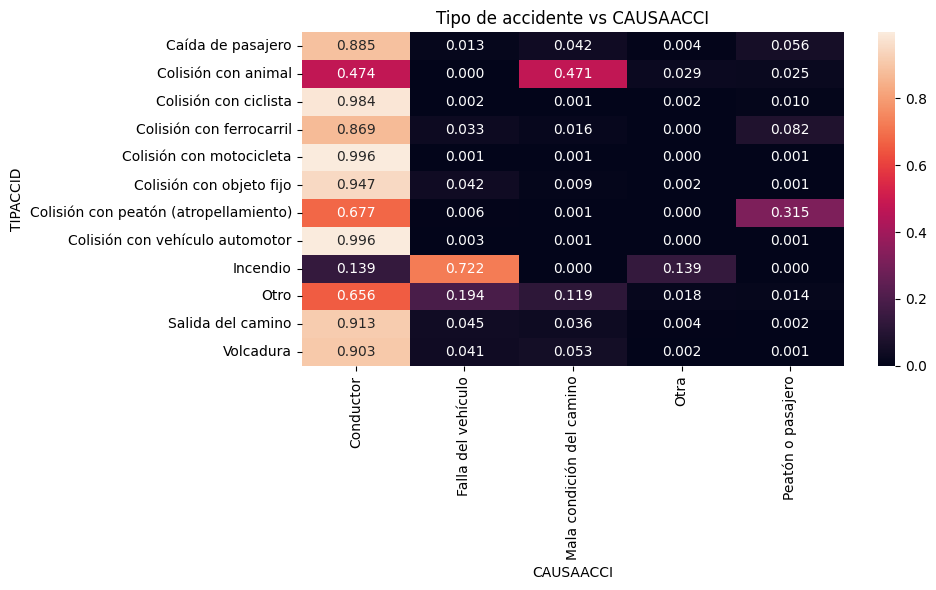

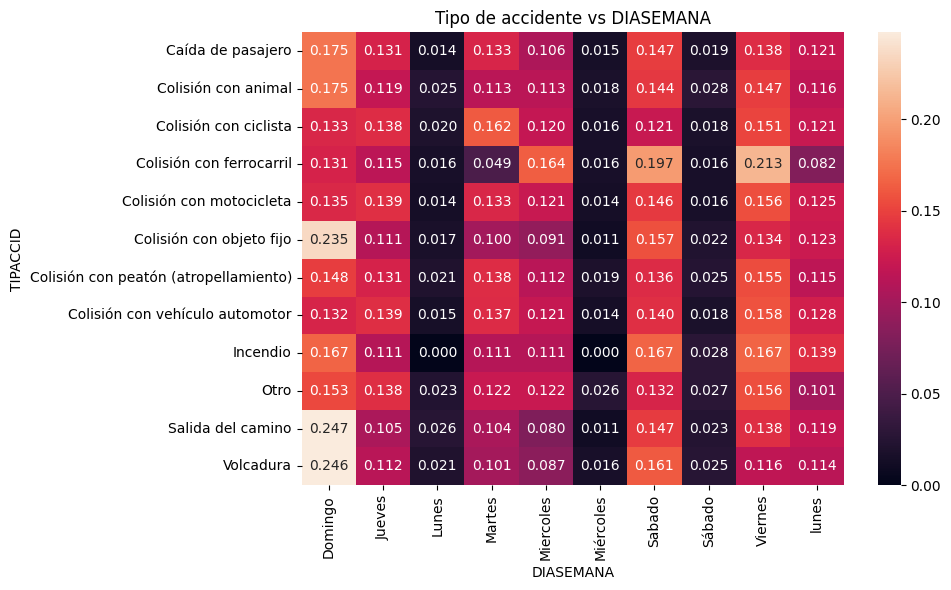

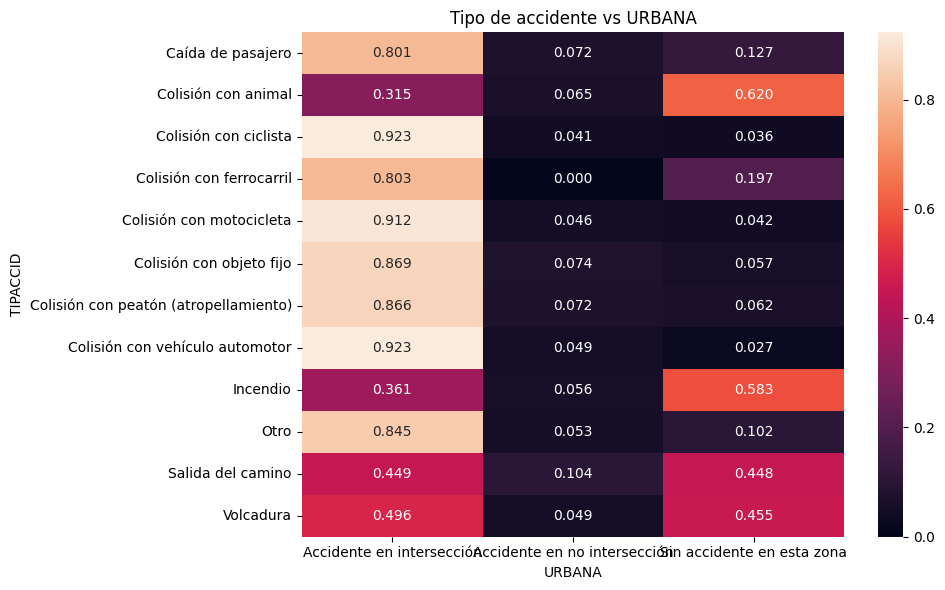

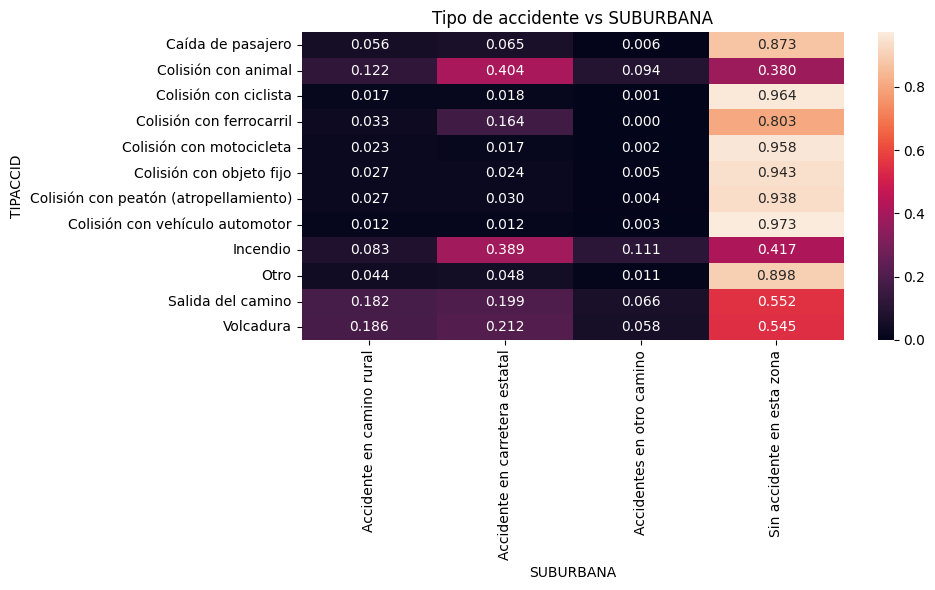

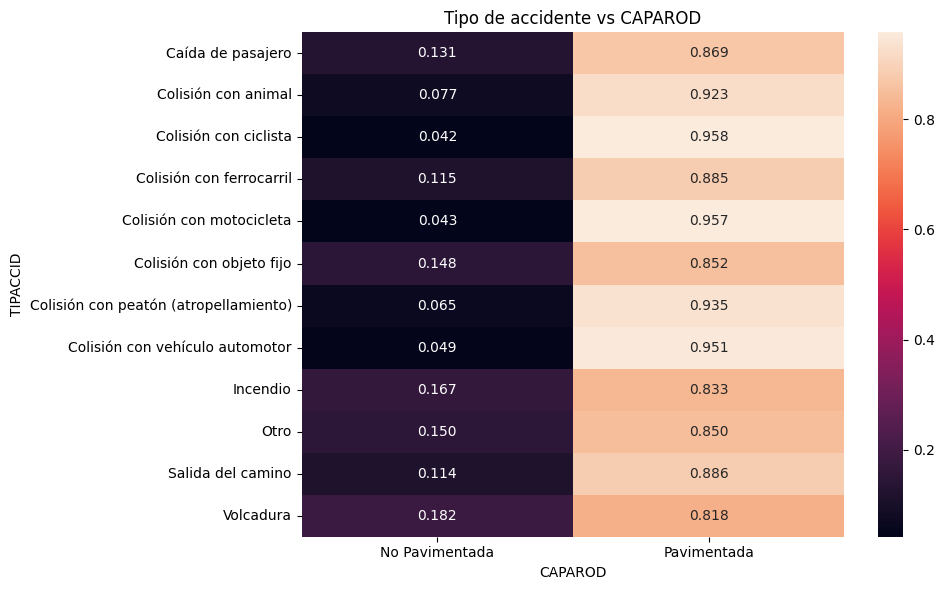

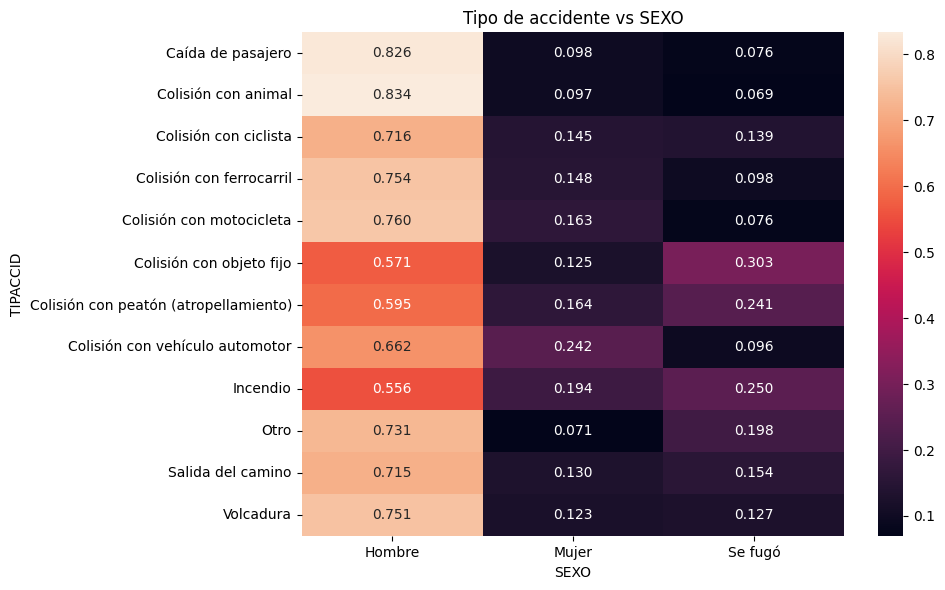

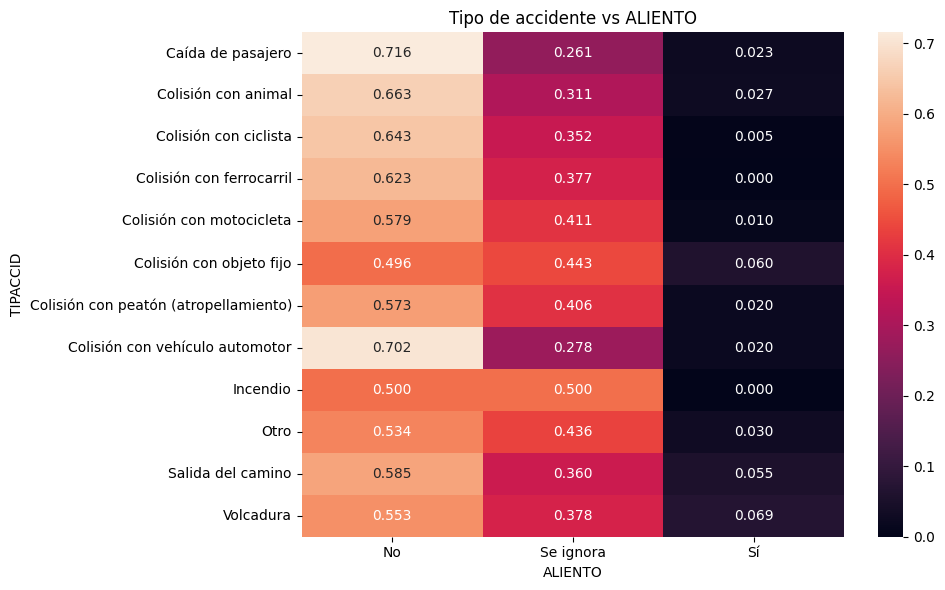

In [7]:
# Columnas categóricas importantes
cat_cols = [
    'CAUSAACCI',
    'DIASEMANA',
    'URBANA',
    'SUBURBANA',
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]

# Heatmaps
for col in cat_cols:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


### Observando relaciones con causa de accidente


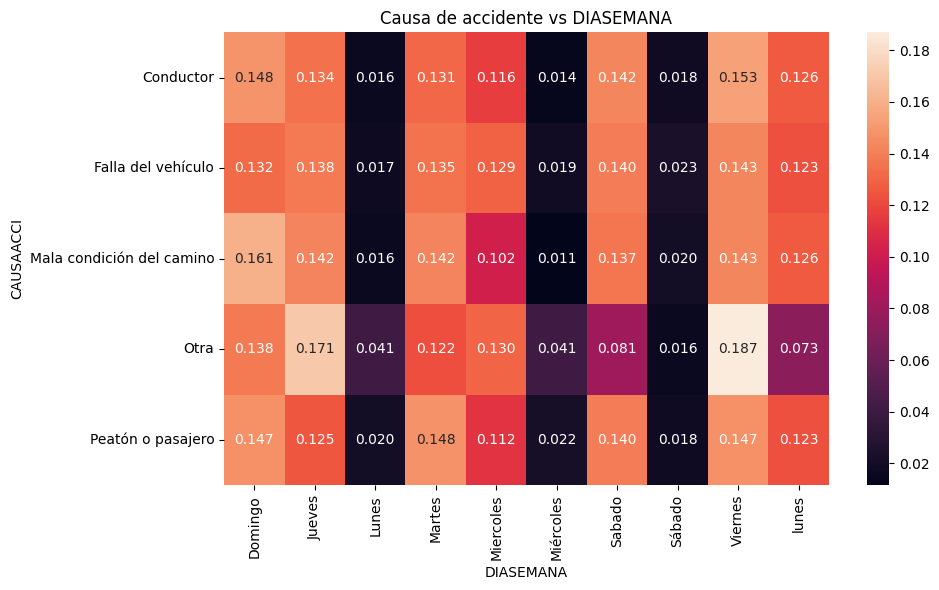

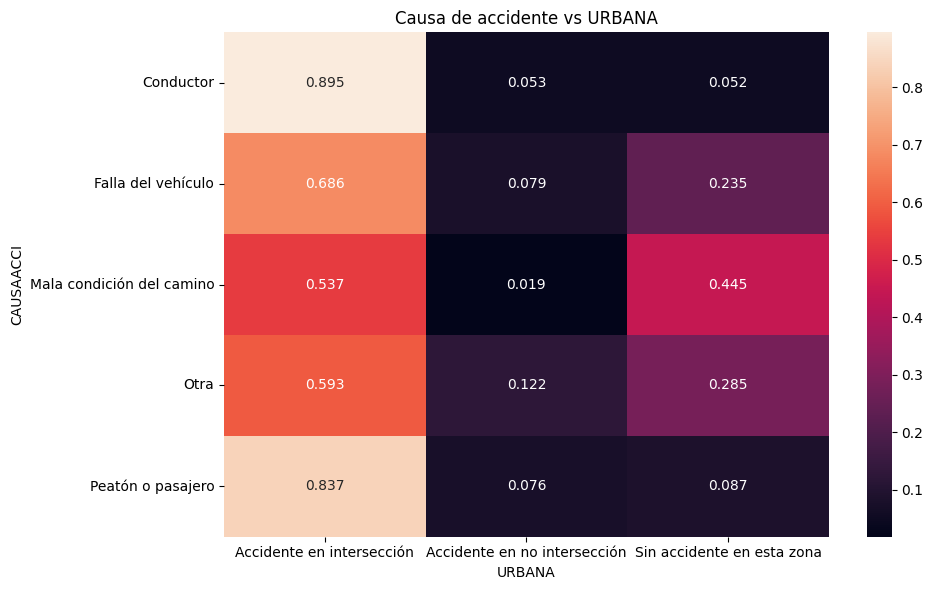

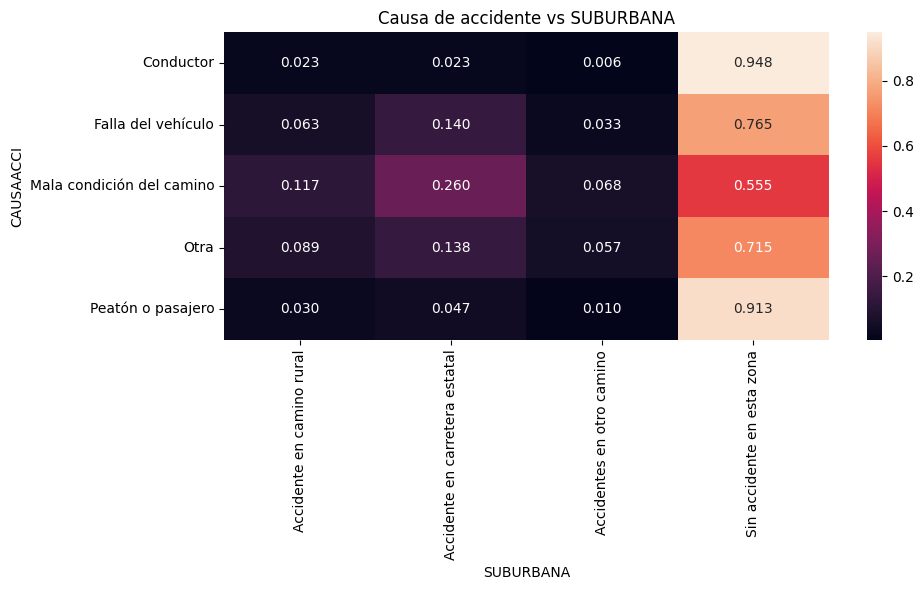

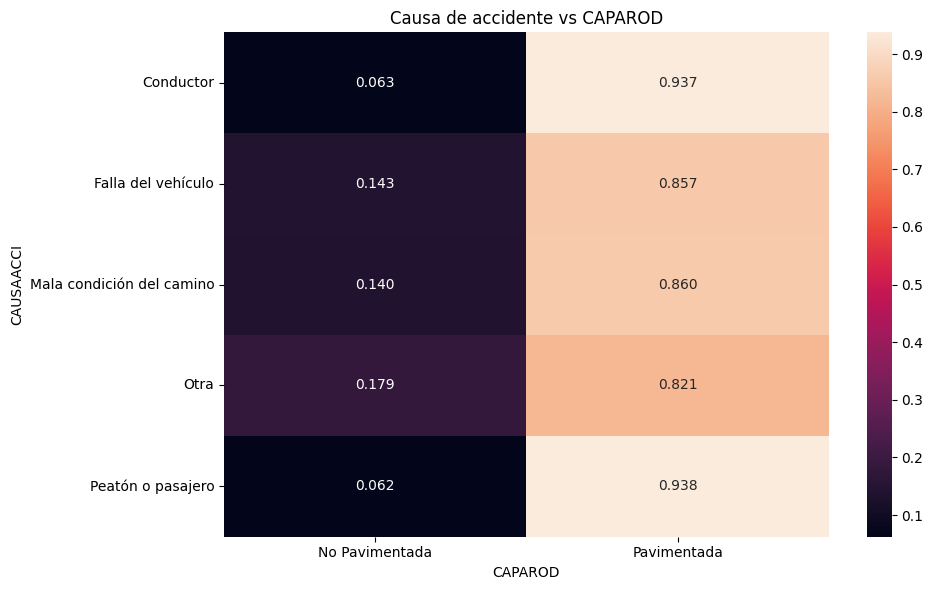

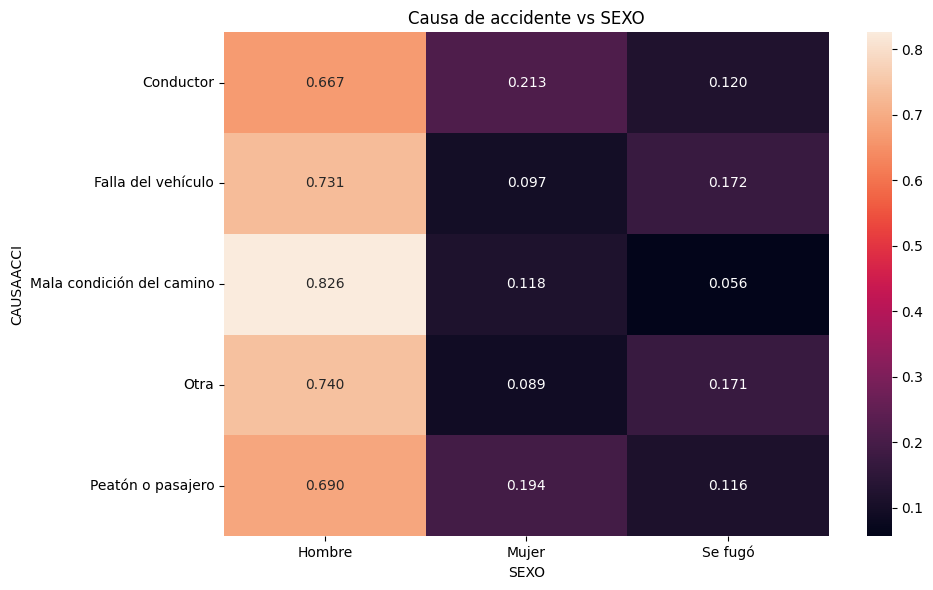

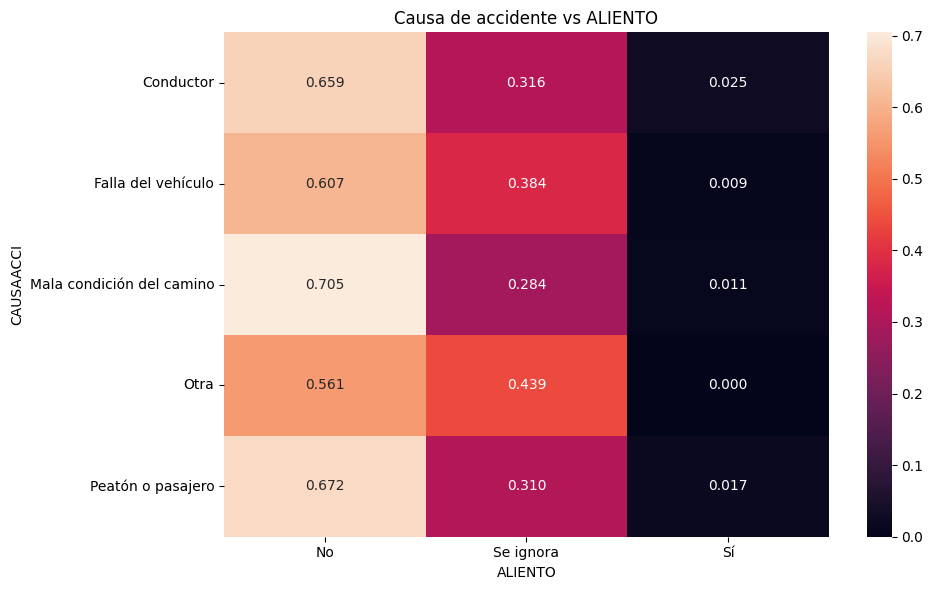

In [8]:
# Columnas categóricas importantes
cat_cols = [
    'DIASEMANA',
    'URBANA',
    'SUBURBANA',
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]

# Heatmaps
for col in cat_cols:

    ct = pd.crosstab(
        inegi_df['CAUSAACCI'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Causa de accidente vs {col}")
    plt.tight_layout()
    plt.show()


### Comparacion de Causa y Tipo de Accidente con tipo de Vehiculo 

#### Causa

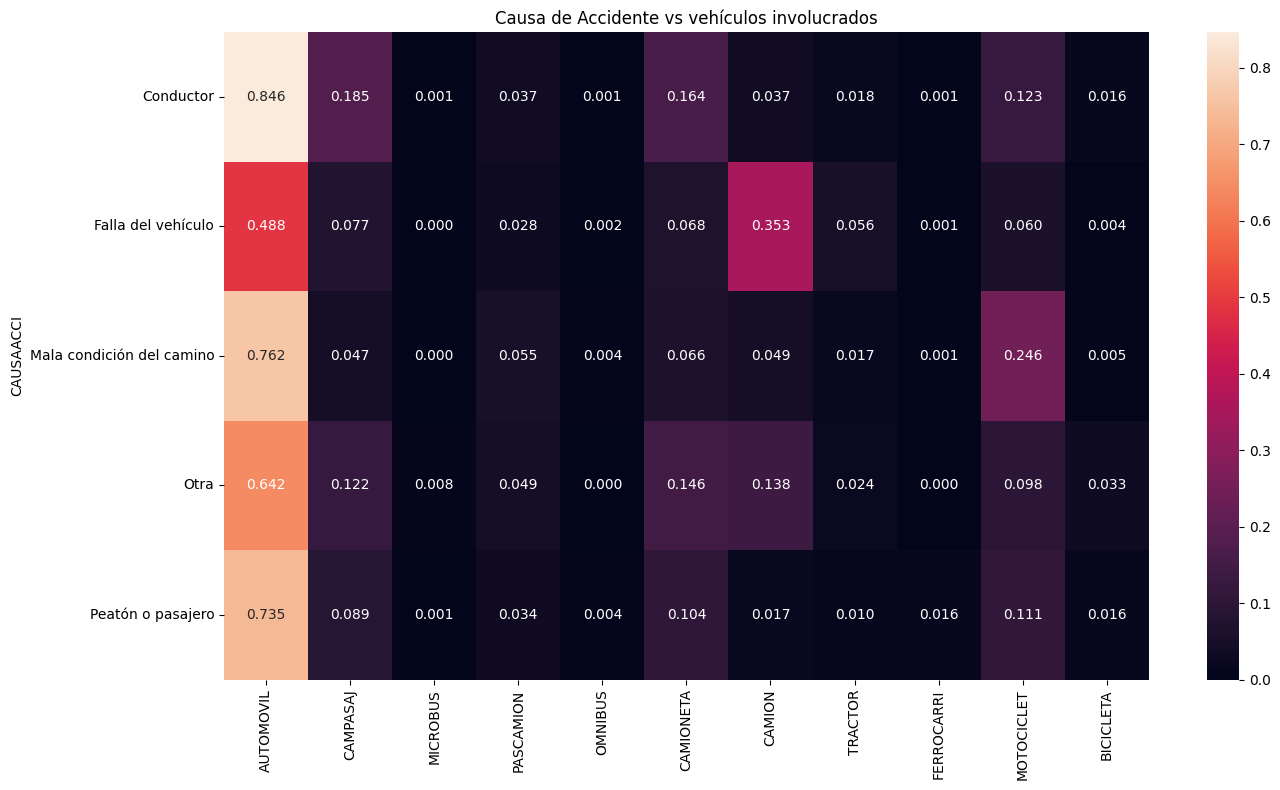

In [13]:
veh_cols = [
    'AUTOMOVIL','CAMPASAJ','MICROBUS','PASCAMION','OMNIBUS',
    'CAMIONETA','CAMION','TRACTOR','FERROCARRI','MOTOCICLET','BICICLETA'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()

#### Tipo

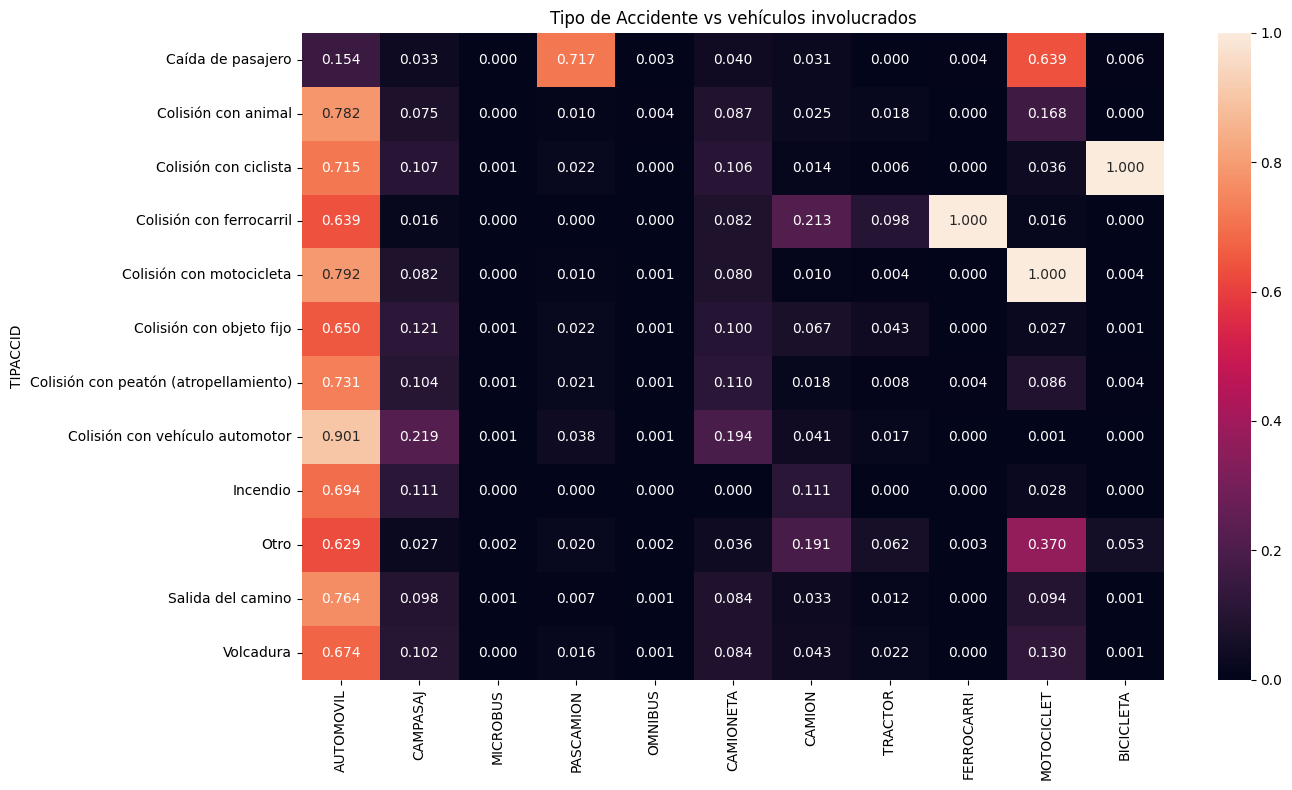

In [14]:
# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()


#### Omitiendo Automovil

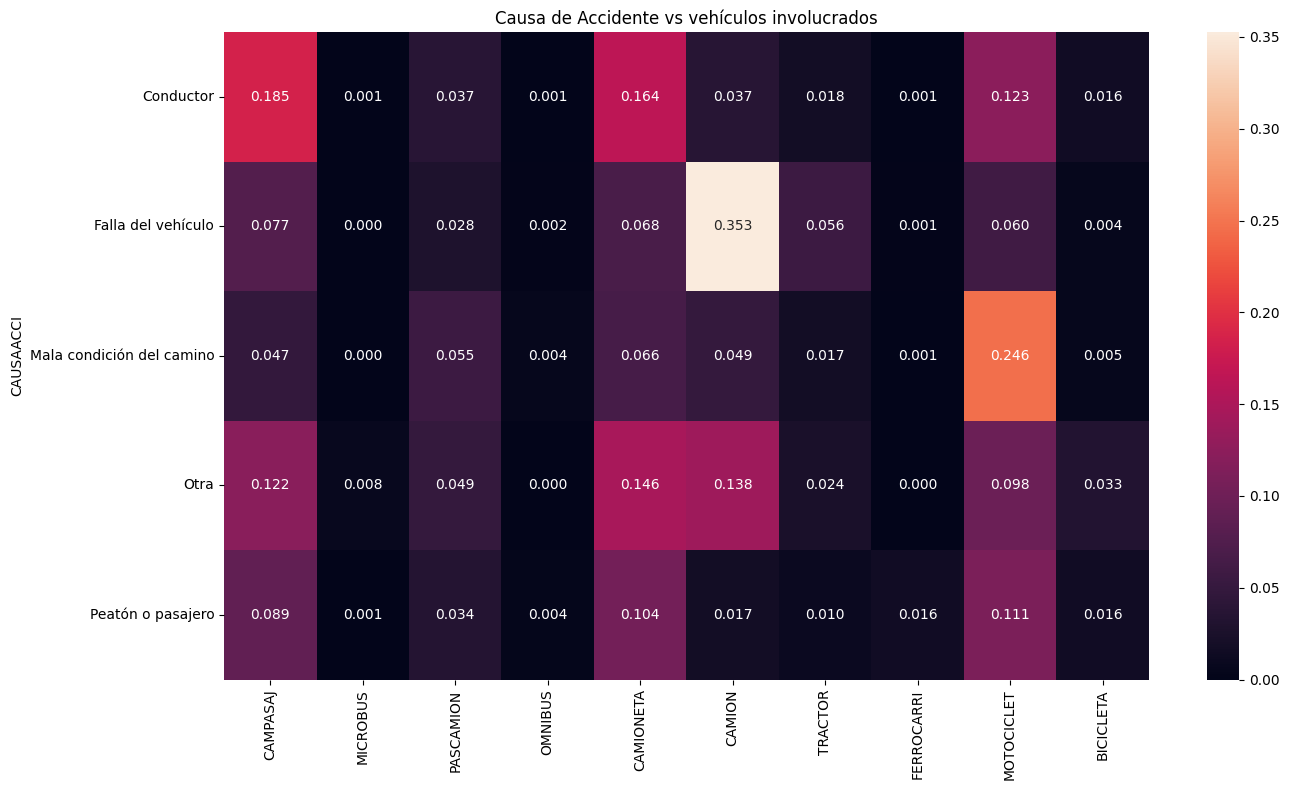

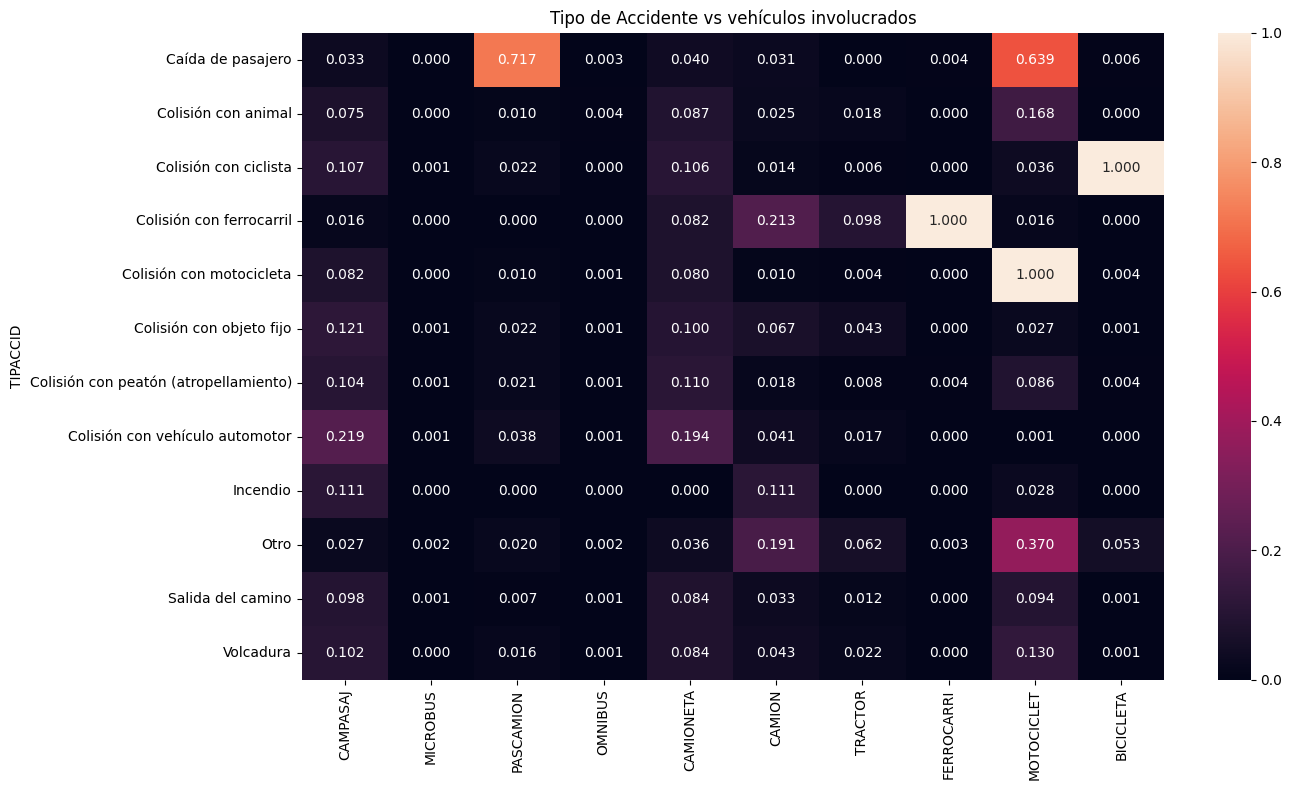

In [16]:
veh_cols = [
    'CAMPASAJ','MICROBUS','PASCAMION','OMNIBUS',
    'CAMIONETA','CAMION','TRACTOR','FERROCARRI','MOTOCICLET','BICICLETA'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()
